# 2020136031 김주상

**파라미터**
- lr : 1e-3
- weight decay : 1e-4
- batch size : 2048
- early_stop : 10 , 0.00001
- normalization type : transforms.Normalize(mean=0.2861, std=0.3204)
- dropout : 0.3, 0.2
- scheduler : StepLR(optimizer, step_size=10, gamma=0.5)
- label smoothing : nn.CrossEntropyLoss(label_smoothing=0.1)

In [1]:
import os
import sys
import argparse
from pathlib import Path
import torch
import wandb
from torchvision import transforms
from torch import nn, optim
from datetime import datetime
from string import Template as DeltaTemplate

from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import transforms

from pathlib import Path


In [ ]:
BASE_PATH = Path('C:\\Users\\USER\\Downloads\\d').resolve()

CHECKPOINT_FILE_PATH = Path(BASE_PATH) / "checkpoints"
CHECKPOINT_FILE_PATH.parent.mkdir(parents=True, exist_ok=True)  # 폴더 없으면 생성

In [2]:
from pathlib import Path
from google.colab import drive

# 구글 드라이브 마운트
drive.mount('/content/drive')

# 기본 경로 설정 (예: /content/drive/MyDrive/딥러닝및실습)
BASE_PATH = Path('/content/drive/MyDrive/딥러닝및실습').resolve()

CHECKPOINT_FILE_PATH = BASE_PATH / "checkpoints"

# 폴더 생성
CHECKPOINT_FILE_PATH.mkdir(parents=True, exist_ok=True)

print("Checkpoint path:", CHECKPOINT_FILE_PATH)


Mounted at /content/drive
Checkpoint path: /content/drive/MyDrive/딥러닝및실습/checkpoints


In [3]:
# from _01_code._09_fcn_best_practice.c_trainer import ClassificationTrainer

class EarlyStopping:
  """Early stops the training if validation loss doesn't improve after a given patience."""
  def __init__(self, patience=3, delta=0.00001, project_name=None, checkpoint_file_path=None, run_time_str=None):
    self.patience = patience
    self.counter = 0
    self.delta = delta

    self.val_loss_min = None
    self.file_path = os.path.join(
      checkpoint_file_path, f"{project_name}_checkpoint_{run_time_str}.pt"
    )
    self.latest_file_path = os.path.join(
      checkpoint_file_path, f"{project_name}_checkpoint_latest.pt"
    )

  def check_and_save(self, new_validation_loss, model):
    early_stop = False

    if self.val_loss_min is None:
      self.val_loss_min = new_validation_loss
      self.save_checkpoint(new_validation_loss, model)
      message = f'Early stopping is stated!'
    elif new_validation_loss < self.val_loss_min - self.delta:
      message = f'V_loss decreased ({self.val_loss_min:7.5f} --> {new_validation_loss:7.5f}). Saving model...'
      self.save_checkpoint(new_validation_loss, model)
      self.val_loss_min = new_validation_loss
      self.counter = 0
    else:
      self.counter += 1
      message = f'Early stopping counter: {self.counter} out of {self.patience}'
      if self.counter >= self.patience:
        early_stop = True
        message += " *** TRAIN EARLY STOPPED! ***"

    return message, early_stop

  def save_checkpoint(self, val_loss, model):
    '''Saves model when validation loss decrease.'''
    torch.save(model.state_dict(), self.file_path)
    torch.save(model.state_dict(), self.latest_file_path)
    self.val_loss_min = val_loss

def strfdelta(td, fmt):

    # Get the timedelta’s sign and absolute number of seconds.
    sign = "-" if td.days < 0 else "+"
    secs = abs(td).total_seconds()

    # Break the seconds into more readable quantities.
    days, rem = divmod(secs, 86400)  # Seconds per day: 24 * 60 * 60
    hours, rem = divmod(rem, 3600)  # Seconds per hour: 60 * 60
    mins, secs = divmod(rem, 60)

    # Format (as per above answers) and return the result string.
    t = DeltaTemplate(fmt)
    return t.substitute(
        s=sign,
        D="{:d}".format(int(days)),
        H="{:02d}".format(int(hours)),
        M="{:02d}".format(int(mins)),
        S="{:02d}".format(int(secs)),
        )

class ClassificationTrainer:
  def __init__(
    self, project_name, model, optimizer, train_data_loader, validation_data_loader, transforms,
    run_time_str, wandb, device, checkpoint_file_path
  ):
    self.project_name = project_name
    self.model = model
    self.optimizer = optimizer
    self.train_data_loader = train_data_loader
    self.validation_data_loader = validation_data_loader
    self.transforms = transforms
    self.run_time_str = run_time_str
    self.wandb = wandb
    self.device = device
    self.checkpoint_file_path = checkpoint_file_path

    self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.5)
    # torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)

    # Use a built-in loss function
    self.loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

  def do_train(self):
    self.model.train()  # Will be explained at 'Diverse Techniques' section

    loss_train = 0.0
    num_corrects_train = 0
    num_trained_samples = 0
    num_trains = 0

    for train_batch in self.train_data_loader:
      input_train, target_train = train_batch
      input_train = input_train.to(device=self.device)
      target_train = target_train.to(device=self.device)

      if self.transforms:
        input_train = self.transforms(input_train)

      output_train = self.model(input_train)
      loss = self.loss_fn(output_train, target_train)
      loss_train += loss.item()

      predicted_train = torch.argmax(output_train, dim=-1)

      # >>> predicted_train: tensor([5, 8, 9, 0, 9, 8, 9, 8, ..., 0, 1, 3, 7, 1, 4, 3])
      # >>> target_train:    tensor([5, 8, 9, 2, 9, 8, 7, 8, ..., 4, 1, 9, 6, 1, 4, 3])
      num_corrects_train += torch.sum(torch.eq(predicted_train, target_train)).item()

      num_trained_samples += len(input_train)
      num_trains += 1

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

    train_loss = loss_train / num_trains
    train_accuracy = 100.0 * num_corrects_train / num_trained_samples

    return train_loss, train_accuracy

  def do_validation(self):
    self.model.eval()   # Explained at 'Diverse Techniques' section

    loss_validation = 0.0
    num_corrects_validation = 0
    num_validated_samples = 0
    num_validations = 0

    with torch.no_grad():
      for validation_batch in self.validation_data_loader:
        input_validation, target_validation = validation_batch
        input_validation = input_validation.to(device=self.device)
        target_validation = target_validation.to(device=self.device)

        if self.transforms:
          input_validation = self.transforms(input_validation)

        output_validation = self.model(input_validation)
        loss_validation += self.loss_fn(output_validation, target_validation).item()

        predicted_validation = torch.argmax(output_validation, dim=1)
        num_corrects_validation += torch.sum(torch.eq(predicted_validation, target_validation)).item()

        num_validated_samples += len(input_validation)
        num_validations += 1

    validation_loss = loss_validation / num_validations
    validation_accuracy = 100.0 * num_corrects_validation / num_validated_samples

    return validation_loss, validation_accuracy

  def train_loop(self):
    early_stopping = EarlyStopping(
      patience=self.wandb.config.early_stop_patience,
      delta=self.wandb.config.early_stop_delta,
      project_name=self.project_name,
      checkpoint_file_path=self.checkpoint_file_path,
      run_time_str=self.run_time_str
    )
    n_epochs = self.wandb.config.epochs
    training_start_time = datetime.now()

    for epoch in range(1, n_epochs + 1):
      train_loss, train_accuracy = self.do_train()

      if epoch == 1 or epoch % self.wandb.config.validation_intervals == 0:
        validation_loss, validation_accuracy = self.do_validation()
        self.scheduler.step(validation_loss)

        elapsed_time = datetime.now() - training_start_time
        epoch_per_second = 0 if elapsed_time.seconds == 0 else epoch / elapsed_time.seconds

        message, early_stop = early_stopping.check_and_save(validation_loss, self.model)

        print(
          f"[Epoch {epoch:>3}] "
          f"T_loss: {train_loss:7.5f}, "
          f"T_accuracy: {train_accuracy:6.4f} | "
          f"V_loss: {validation_loss:7.5f}, "
          f"V_accuracy: {validation_accuracy:6.4f} | "
          f"{message} | "
          f"T_time: {strfdelta(elapsed_time, '%H:%M:%S')}, "
          f"T_speed: {epoch_per_second:4.3f}"
        )

        self.wandb.log({
          "Epoch": epoch,
          "Training loss": train_loss,
          "Training accuracy (%)": train_accuracy,
          "Validation loss": validation_loss,
          "Validation accuracy (%)": validation_accuracy,
          "Training speed (epochs/sec.)": epoch_per_second,
        })

        if early_stop:
          break

    elapsed_time = datetime.now() - training_start_time
    print(f"Final training time: {strfdelta(elapsed_time, '%H:%M:%S')}")


In [4]:
# from _01_code._09_fcn_best_practice.e_arg_parser import get_parser
def get_parser():
  parser = argparse.ArgumentParser()

  parser.add_argument(
    "--wandb", action=argparse.BooleanOptionalAction, default=True, help="True or False"
  )

  parser.add_argument(
    "-b", "--batch_size", type=int, default=512, help="Batch size (int, default: 2_048)"
  )

  parser.add_argument(
    "-e", "--epochs", type=int, default=10_000, help="Number of training epochs (int, default:10_000)"
  )

  parser.add_argument(
    "-r", "--learning_rate", type=float, default=1e-3, help="Learning rate (float, default: 1e-3)"
  )

  parser.add_argument(
    "-v", "--validation_intervals", type=int, default=1,
    help="Number of training epochs between validations (int, default: 1)"
  )

  parser.add_argument(
    "-p", "--early_stop_patience", type=int, default=10,
    help="Number of early stop patience (int, default: 10)"
  )

  parser.add_argument(
    "-d", "--early_stop_delta", type=float, default=0.00001,
    help="Delta value of early stop (float, default: 0.00001)"
  )

  return parser


In [5]:
# from _01_code._99_common_utils.utils import get_num_cpu_cores, is_linux, is_windows
def get_num_cpu_cores():
    import multiprocessing
    return multiprocessing.cpu_count()

def is_linux():
    if sys.platform.startswith("linux"):
        return True
    else:
        return False

def is_windows():
    if os.name == "nt":
        return True
    else:
        return False


In [6]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# 문제 1

In [7]:
# 데이터

def get_mean_std(loader):
    mean = 0.0
    std = 0.0
    total = 0

    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total += batch_samples

    mean /= total
    std /= total
    return mean, std    # mean: tensor([0.2861]), std: tensor([0.3204])

def get_fashion_mnist_data():
    data_path = os.path.join(BASE_PATH, "_00_data", "j_fashion_mnist")

    f_mnist_train = datasets.FashionMNIST(data_path, train=True, download=True, transform=transforms.ToTensor())
    f_mnist_train, f_mnist_validation = random_split(f_mnist_train, [55_000, 5_000])

    print("Num Train Samples: ", len(f_mnist_train))
    print("Num Validation Samples: ", len(f_mnist_validation))
    print("Sample Shape: ", f_mnist_train[0][0].shape)  # torch.Size([1, 28, 28])

    num_data_loading_workers = get_num_cpu_cores() if is_linux() or is_windows() else 0
    print("Number of Data Loading Workers:", num_data_loading_workers)

    train_data_loader = DataLoader(
        dataset=f_mnist_train, batch_size=wandb.config.batch_size, shuffle=True,
        pin_memory=True, num_workers=num_data_loading_workers # pin_memory = GPU 사용할때는 해야함
    )

    validation_data_loader = DataLoader(
        dataset=f_mnist_validation, batch_size=wandb.config.batch_size,
        pin_memory=True, num_workers=num_data_loading_workers
    )

    mean, std = get_mean_std(train_data_loader)
    print(f"mean: {mean}, std: {std}")

    f_mnist_transforms = nn.Sequential(
        transforms.ConvertImageDtype(torch.float),
        # transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
    )

    return train_data_loader, validation_data_loader, f_mnist_transforms, mean, std

def get_fashion_mnist_test_data(mean, std):
    # **** 어짜피 mean, std값은 변하지 않아서 그냥 위에서 구한거 그대로 썼습니다. ****
    data_path = os.path.join(BASE_PATH, "j_fashion_mnist")

    f_mnist_test_images = datasets.FashionMNIST(data_path, train=False, download=True)
    f_mnist_test = datasets.FashionMNIST(data_path, train=False, download=True, transform=transforms.ToTensor())

    print("Num Test Samples: ", len(f_mnist_test))
    print("Sample Shape: ", f_mnist_test[0][0].shape)  # torch.Size([1, 28, 28])

    test_data_loader = DataLoader(dataset=f_mnist_test, batch_size=len(f_mnist_test))

    f_mnist_transforms = nn.Sequential(
        transforms.ConvertImageDtype(torch.float),
        # transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
    )

    return f_mnist_test_images, test_data_loader, f_mnist_transforms


# 문제 2

In [9]:
# colab
# !pip install torchinfo

In [10]:
# 학습
def get_cnn_model():
  class MyModel(nn.Module):
    def __init__(self, in_channels, n_output):
      super().__init__()

      self.features = nn.Sequential(
        nn.Conv2d(1, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),

        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(256, 512, 3, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(),
        nn.MaxPool2d(2),
      )

      self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(512 * 3 * 3, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, 10)
      )

    def forward(self, x, **kwargs):
      x = self.features(x)
      x = self.classifier(x)
      return x

  # 1 * 28 * 28
  my_model = MyModel(in_channels=1, n_output=10)

  return my_model


mean, std = 0, 0

def main(args):
  global mean, std
  run_time_str = datetime.now().astimezone().strftime('%Y-%m-%d_%H-%M-%S')

  config = {
    'epochs': args.epochs,
    'batch_size': args.batch_size,
    'validation_intervals': args.validation_intervals,
    'learning_rate': args.learning_rate,
    'early_stop_patience': args.early_stop_patience,
    'early_stop_delta': args.early_stop_delta
  }

  project_name = "cnn_mnist"
  wandb.init(
    mode="online" if args.wandb else "disabled",
    project=project_name,
    notes="mnist experiment with cnn",
    tags=["cnn", "mnist"],
    name=run_time_str,
    config=config
  )
  print(args)
  print(wandb.config)

  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  print(f"Training on device {device}.")

  train_data_loader, validation_data_loader, f_mnist_transforms, mean, std = get_fashion_mnist_data()
  model = get_cnn_model()
  model.to(device)

  from torchinfo import summary

  info = summary(model, input_size=(1, 1, 28, 28), depth=50, print_summary=False)
  print(" - print torchinfo -")
  print(info)

  optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate, weight_decay=1e-4)

  classification_trainer = ClassificationTrainer(
    project_name, model, optimizer, train_data_loader, validation_data_loader, f_mnist_transforms,
    run_time_str, wandb, device, CHECKPOINT_FILE_PATH
  )
  classification_trainer.train_loop()

  wandb.finish()

if __name__ == "__main__":
    config = {'batch_size': 2048, }
    wandb.init(mode="online", config=config)

    # [K] f_mnist_test_images, test_data_loader = get_fashion_mnist_test_data()

    parser = get_parser()
    args = parser.parse_args([])
    main(args)


Namespace(wandb=True, batch_size=512, epochs=10000, learning_rate=0.001, validation_intervals=1, early_stop_patience=10, early_stop_delta=1e-05)
{'epochs': 10000, 'batch_size': 512, 'validation_intervals': 1, 'learning_rate': 0.001, 'early_stop_patience': 10, 'early_stop_delta': 1e-05}
Training on device cuda:0.
Num Train Samples:  55000
Num Validation Samples:  5000
Sample Shape:  torch.Size([1, 28, 28])
Number of Data Loading Workers: 2
mean: tensor([0.2863]), std: tensor([0.3206])
 - print torchinfo -
Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 512, 3, 3]            --
│    └─Conv2d: 2-1                       [1, 64, 28, 28]           640
│    └─BatchNorm2d: 2-2                  [1, 64, 28, 28]           128
│    └─ReLU: 2-3                         [1, 64, 28, 28]           --
│    └─Conv2d: 2-4                       [1, 128, 28, 28]      

Epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
Training accuracy (%),▁▅▅▆▆▆▆▇▇▇▇▇███████████
Training loss,█▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
Training speed (epochs/sec.),▆▆▆▆█▆▄▄▄▃▄▃▂▂▂▂▂▂▁▁▁▁▁
Validation accuracy (%),▁▄▅▅▆▇▇▇▇▇███▇█▇▇███▇▇▇
Validation loss,█▅▄▄▃▂▂▂▂▂▁▁▁▂▁▂▁▁▁▁▂▂▂
Epoch,23
Training accuracy (%),99.57091
Training loss,0.53964
Training speed (epochs/sec.),0.04904
Validation accuracy (%),93.98


# 문제 3

In [11]:
def test_latest_model(model_class, checkpoint_path, device):
    # 1. 모델 생성
    model = model_class()
    model.to(device)

    # 2. latest 체크포인트 불러오기
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    # 3. 테스트 데이터 로드 및 transform 적용
    _, test_loader, test_transforms = get_fashion_mnist_test_data(mean, std)  # batch_size = 전체 test 데이터
    test_loader = [(test_transforms(images.to(device)), labels.to(device)) for images, labels in test_loader]

    # 4. 평가
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct = (predicted == labels).sum().item()
            total = labels.size(0)

    accuracy = 100.0 * correct / total
    print(f"Test Accuracy: {accuracy:.4f}%")
    return accuracy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint_path = os.path.join(CHECKPOINT_FILE_PATH, "cnn_mnist_checkpoint_latest.pt")
test_accuracy = test_latest_model(get_cnn_model, checkpoint_path, device)
print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Num Test Samples:  10000
Sample Shape:  torch.Size([1, 28, 28])
Test Accuracy: 93.9200%
Final Test Accuracy: 93.92%


# 문제 4

답 : Ankle boot<br>
예측 : Sandle<br>
이유 : Sandle은 대체적으로 비어있는 부분이 많고 Ankle boot는 꽉차있는 느낌인데, <br>내부에 있는 검은색 빈 곳이 있어서 Ankle boot라 예측한것 같다.<br>

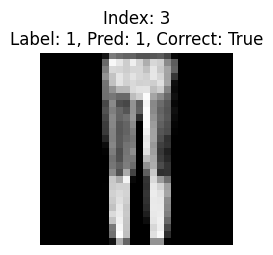

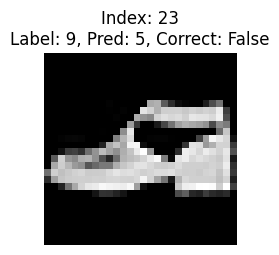

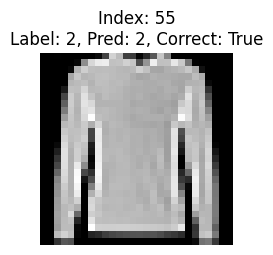

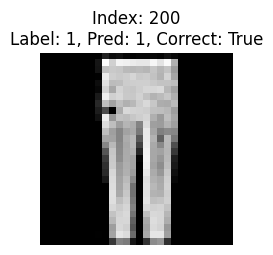

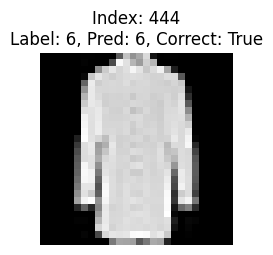

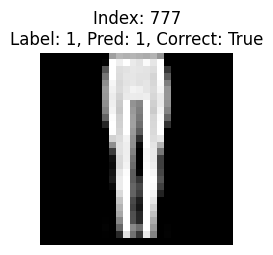

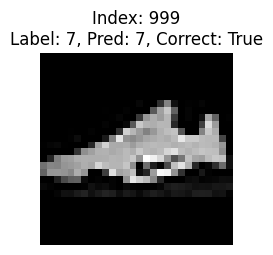

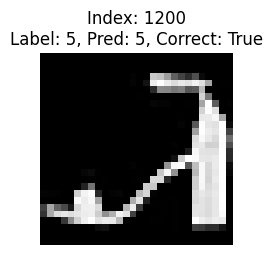

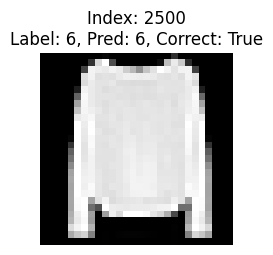

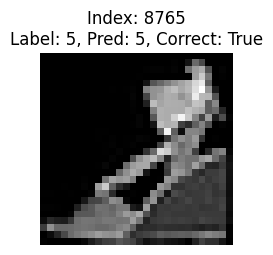

In [12]:
import matplotlib.pyplot as plt

def show_selected_test_results(model, device, test_data_loader, transforms, idx_list):
    """
    선택한 테스트 인덱스에 대해
    - 이미지 출력
    - 실제 레이블 출력
    - 모델 예측값 출력
    - 맞았는지 여부 표시
    """
    model.eval()

    for images, labels in test_data_loader:
        break
    images = images.to(device)
    labels = labels.to(device)

    for idx in idx_list:
        img = images[idx]
        label = labels[idx].item()

        img_t = transforms(img.unsqueeze(0))

        # 모델 예측
        with torch.no_grad():
            out = model(img_t)
            pred = torch.argmax(out, dim=1).item()

        is_correct = (pred == label)

        # 이미지와 결과 출력
        plt.figure(figsize=(2.5, 2.5))
        plt.imshow(img.cpu().squeeze(), cmap='gray')
        plt.title(f"Index: {idx}\nLabel: {label}, Pred: {pred}, Correct: {is_correct}")
        plt.axis('off')
        plt.show()

model = get_cnn_model()
checkpoint_file = CHECKPOINT_FILE_PATH / "cnn_mnist_checkpoint_latest.pt"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(checkpoint_file, map_location=device))
model.to(device)
model.eval()

test_dataset = datasets.FashionMNIST(BASE_PATH / "j_fashion_mnist", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))  # 전체 데이터 한 번에 로드

test_transforms = nn.Sequential(
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=0.2861, std=0.3204)
)

idx_list = [3, 23, 55, 200, 444, 777, 999, 1200, 2500, 8765]

show_selected_test_results(model, device, test_loader, test_transforms, idx_list)


이번 실습을 통해 CNN 모델이 이미지 분류에서는 굉장히 강력하다는 알 수 있었다. 하지만, 일부 검증 데이터에서 오답이 나오는 걸 보면서 모델이 모든 상황을 완벽히 이해하는 건 어렵다는 걸 체감했다. 특히 위에 있는 23 데이터의 경우에는 모델을 수십번 돌려보아도 동일하게 틀리는것을 볼수 있었는데, 사람은 신발의 모양세나 특징을 통해서 사람이라면 충분히 부츠임을 알수 있지만, 일부 특징만으로 검증해야 하는 ai는 구분하지 못했다.

모델에서의 conv, ff의 수를 늘려도 보고 줄여도 보며 테스트 했는데, 너무 줄어드는게 아닌 이상 결과는 어느정도 동일하게 나온 것을 보아, 이미지가 갖는 특징의 개수 이상으로 레이어를 늘리는것은 그냥 연산 낭비라는 것을 깨닳았다. 또한 이미지에 변형도 가해 봤는데, 오히려 이미지에 변형하지 않은것에 비해 정확도가 떨어지는 것을 보아, 간단한 데이터에 노이즈나 변형은 오히려 방해가 될 수 있음을 알았다. Drop out을 쓰지 않을때와 썼을때(0.3, 0.2), 너무 과하게(0.5, 0.5)적용했을때를 테스트 해보았을때, Drop out을 쓰면 모델이 좋아지지만, 너무 많이 넣으면 안넣은 것 만도 못한다는 것을 알게 되었다.